# Imports

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, PowerTransformer
from sklearn.decomposition import PCA as skPCA
from sklearn.compose import ColumnTransformer

from sklearn.cluster import KMeans, DBSCAN, MiniBatchKMeans, AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples

from sklearn.metrics.cluster import adjusted_rand_score

In [122]:
df = pd.read_csv('data/clean_df_customers.csv')
df.set_index('customer_unique_id', inplace=True)

df

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message,max_order_date
customer_unique_id,,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0,2017-10-02
af07308b275d755c9edb36a90c618231,85,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,118.7,22.76,0,4,100.0,2018-07-24
3a653a41f6f9fc3d2a113cf8398680e8,70,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.22,1,5,0.0,2018-08-08
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0,2017-11-18
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0,2018-02-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.08,1,1,0.0,2017-03-09
da62f9e57a76d978d02ab5362c509660,253,174.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.10,0,5,100.0,2018-02-06
737520a9aad80b3fbbdad19b66b37b30,416,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65.02,0,5,100.0,2017-08-27


In [123]:
offset = -2
n_periods = 18

#list_offsets = [i for i in range(n_offset, n_periods+n_offset, n_offset)]
list_offsets = list(range(n_periods, 0, offset))
list_offsets

[18, 16, 14, 12, 10, 8, 6, 4, 2]

In [124]:
offset = -1
n_periods_max = 24
n_periods_min = 8

#list_offsets = [i for i in range(n_offset, n_periods+n_offset, n_offset)]
list_offsets = list(range(n_periods_max, n_periods_min, offset))
list_offsets

[24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9]

In [125]:
min_date = pd.to_datetime(df['max_order_date'].min())
max_date = pd.to_datetime(df['max_order_date'].max())

print(min_date.strftime('%Y-%m-%d'))
print(max_date.strftime('%Y-%m-%d'))

2016-09-04
2018-10-16


In [126]:
n_period_sp = 5
limit_date = (max_date - pd.DateOffset(weeks=list_offsets[n_period_sp])).strftime('%Y-%m-%d')

print (f"Date max {max_date.strftime('%Y-%m-%d')} après retrait de {n_period_sp} semaines : {limit_date}")

Date max 2018-10-16 après retrait de 5 semaines : 2018-06-05


In [127]:
dfs = {}

#list_n_df
#len_offsets = len(list_offsets)
#offsets_count = list(range(1, len_offsets, 1))
n = 1

for i in list_offsets:
    subset = df[df['max_order_date'] <= (max_date - pd.DateOffset(weeks=i)).strftime('%Y-%m-%d')]
    #dfs[f'df_{i}'] = subset
    dfs[f'df_{n}'] = subset
    n+=1

print(dfs.keys())

dict_keys(['df_1', 'df_2', 'df_3', 'df_4', 'df_5', 'df_6', 'df_7', 'df_8', 'df_9', 'df_10', 'df_11', 'df_12', 'df_13', 'df_14', 'df_15', 'df_16'])


In [128]:
for name, df in dfs.items():
    print(f'{name}: shape {df.shape}, max date {df['max_order_date'].max()}')
    #print()

df_1:
(70274, 15)
2018-05-01

df_2:
(72207, 15)
2018-05-08

df_3:
(74162, 15)
2018-05-15

df_4:
(75654, 15)
2018-05-22

df_5:
(76482, 15)
2018-05-29

df_6:
(77665, 15)
2018-06-05

df_7:
(79203, 15)
2018-06-12

df_8:
(80637, 15)
2018-06-19

df_9:
(82082, 15)
2018-06-26

df_10:
(83391, 15)
2018-07-03

df_11:
(84441, 15)
2018-07-10

df_12:
(85598, 15)
2018-07-17

df_13:
(87337, 15)
2018-07-24

df_14:
(88976, 15)
2018-07-31

df_15:
(91140, 15)
2018-08-07

df_16:
(92962, 15)
2018-08-14



In [129]:
# drop max_order_date column
for name, df in dfs.items():
    df = df.drop('max_order_date', axis=1)
    dfs[name] = df

for name, df in dfs.items():
    print(f'{name}: {df.shape}')
    #print()

df_1:
(70274, 14)

df_2:
(72207, 14)

df_3:
(74162, 14)

df_4:
(75654, 14)

df_5:
(76482, 14)

df_6:
(77665, 14)

df_7:
(79203, 14)

df_8:
(80637, 14)

df_9:
(82082, 14)

df_10:
(83391, 14)

df_11:
(84441, 14)

df_12:
(85598, 14)

df_13:
(87337, 14)

df_14:
(88976, 14)

df_15:
(91140, 14)

df_16:
(92962, 14)



In [130]:
dfs['df_1']

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
customer_unique_id,,,,,,,,,,,,,,
7c396fd4830fd04220f754e42b4e5bff,380,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0
7c142cf63193a1473d2e66489a9ae977,333,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45.0,27.20,1,3,100.0
72632f0f9dd73dfee390c9b22eb56dd6,246,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,19.9,8.72,0,5,0.0
80bb27c7c16e8f973207a5086ab329e2,465,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.36,0,4,0.0
36edbb3fb164b1f16485364b6fb04c73,554,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,16.05,1,5,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6359f309b166b0196dbf7ad2ac62bb5a,587,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.08,1,1,0.0
da62f9e57a76d978d02ab5362c509660,253,174.90,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.10,0,5,100.0
737520a9aad80b3fbbdad19b66b37b30,416,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,65.02,0,5,100.0


# train kmeans datasets

In [131]:
skewness = dfs['df_1'].select_dtypes(include=np.number).skew()
treshold_skew = 1.0
cols_skewed = skewness[skewness > treshold_skew].index.tolist()
cols_unskewed = skewness[skewness < treshold_skew].index.tolist()

print("Colonnes numériques avec une skewness supérieure à la limite :")
print(cols_skewed)
print(cols_unskewed)


Colonnes numériques avec une skewness supérieure à la limite :
['baby', 'computers', 'fixed_telephony', 'furniture_decor', 'musical_instruments', 'sports_leisure', 'telephony', 'toys', 'other_categories', 'freight_value', 'frequency_medium']
['recency', 'mean_review_score', 'ratio_comment_message']


In [132]:
def customTransform(df, cols_skewed, cols_unskewed):
    # sélection colonnes avec skewness élevée :
    
    # Création du ColumnTransformer
    transformer = ColumnTransformer([
        #('minmax', MinMaxScaler(), cols_skewed),
        ('power', PowerTransformer(), cols_skewed),
        ('standard', StandardScaler(), cols_unskewed)
    ])
    
    X_std = pd.DataFrame(transformer.fit_transform(df), columns=df.columns)
    return X_std

In [133]:
# drop max_order_date column
X_stds = {}

for name, df in dfs.items():
    df = customTransform(df, cols_skewed, cols_unskewed)
    name_split = name.split("_")
    X_stds[f'X_{name_split[1]}'] = df

In [134]:
X_stds.keys()

dict_keys(['X_1', 'X_2', 'X_3', 'X_4', 'X_5', 'X_6', 'X_7', 'X_8', 'X_9', 'X_10', 'X_11', 'X_12', 'X_13', 'X_14', 'X_15', 'X_16'])

In [135]:
for name, df in X_stds.items():
    print(f'{name}: {df.shape}')
    #print()

X_1:
(70274, 14)

X_2:
(72207, 14)

X_3:
(74162, 14)

X_4:
(75654, 14)

X_5:
(76482, 14)

X_6:
(77665, 14)

X_7:
(79203, 14)

X_8:
(80637, 14)

X_9:
(82082, 14)

X_10:
(83391, 14)

X_11:
(84441, 14)

X_12:
(85598, 14)

X_13:
(87337, 14)

X_14:
(88976, 14)

X_15:
(91140, 14)

X_16:
(92962, 14)



In [137]:
X_stds['X_1']

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
0,5.824726,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,-0.120824,1.508335,0.227862,-0.013716,1.189009
1,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,1.778627,0.660092,1.508335,-0.143800,-0.731422,1.189009
2,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,1.693516,-1.407849,-0.661969,-0.831770,0.703990,-0.846335
3,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,0.670124,-0.661969,0.900017,-0.013716,-0.846335
4,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,1.785893,-0.271051,1.508335,1.603803,0.703990,1.189009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70269,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,-0.646300,1.508335,1.864757,-2.166834,-0.846335
70270,5.824726,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,0.132918,-0.661969,-0.776416,0.703990,1.189009
70271,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,2.066679,-0.661969,0.512539,0.703990,1.189009
70272,-0.171682,-0.045628,-0.049389,-0.271698,-0.08001,-0.301254,-0.220134,-0.216377,-0.558712,2.397529,-0.661969,-0.547093,0.703990,1.189009


## Check training first dataset

In [ ]:
X_std = X_stds['X_1'].copy()

# Calcul du score de silhouette pour chaque valeur de n_clusters comprise entre 2 et 15
n_clusters_range = range(2, 16)
scores = []

columns = X_std.columns

for n_clusters in n_clusters_range:
    # Initialisation de KMeans avec kmeans++
    
    #kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, random_state=42)
    #kmeans.fit(X_std)
    #labels = kmeans.labels_
    #score = silhouette_score(X_std, labels)
    #print(f'Kmeans sil score : {score}')
    #scores.append(score)

    # Initialisation de MiniBatchKMeans
    mbkmeans = MiniBatchKMeans(n_clusters=n_clusters, init='k-means++', n_init=10, max_iter=300, batch_size=100, random_state=42)
    mbkmeans.fit(X_std)
    labels_mb = mbkmeans.labels_
    score_mb = silhouette_score(X_std, labels_mb)
    print(f'BatchKmeans {n_clusters} clusters, sil score : {score_mb}')
    scores.append(score_mb)

# Tracé du graphique des scores de silhouette
plt.plot(n_clusters_range, scores)
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Scores de silhouette en fonction du nombre de clusters')
plt.show()

# Sélection de la valeur de n_clusters qui donne le score de silhouette le plus élevé
best_score = max(scores)
best_index = scores.index(best_score)
best_n_clusters = best_index + 2

print(f"Le nombre optimal de clusters est : {best_n_clusters}")

BatchKmeans 2 clusters, sil score : 0.3056344026555471
BatchKmeans 3 clusters, sil score : 0.08568404372720909
BatchKmeans 4 clusters, sil score : 0.1502209375168653
BatchKmeans 5 clusters, sil score : 0.10916082303061077
BatchKmeans 6 clusters, sil score : 0.18432693549636212
BatchKmeans 7 clusters, sil score : 0.17727943073023178
BatchKmeans 8 clusters, sil score : 0.18276398921690945
BatchKmeans 9 clusters, sil score : 0.19449963702222614
BatchKmeans 10 clusters, sil score : 0.2348237990551
BatchKmeans 11 clusters, sil score : 0.2077862119780893


In [ ]:
sorted_scores = np.argsort(scores)[::-1]
top_indices = sorted_scores[:5]

print("Les 5 plus grands score de silhouette sont :")

for indice in top_indices:
    print(f"{indice+2} clusters pour {scores[indice]} score de silhouette")

In [ ]:
inertia = {}
dict_kmeans = {}
for k in range(1,25):
    print(k)
    kmeans = KMeans(n_clusters=k,
                   verbose=1,
                   random_state=0
                   ).fit(X_std)
    inertia[k] = kmeans.inertia_
    dict_kmeans[k] = kmeans

In [ ]:
plt.figure(figsize=(8,5))
plt.title('Kmeans : Comparaison de la somme des inerties en fonction du nombre de clusters')
sns.lineplot(x=list(inertia.keys()),
             y=list(inertia.values())
            )

### Train and compare through time

In [116]:
clusters_num = 11

dict_Kmeans_X = {}

for name, df in X_stds.items():
    kmeans = KMeans(n_clusters=clusters_num, verbose=1, random_state=0).fit(df)
    dict_Kmeans_X[f'kmeans_{name}'] = kmeans

Initialization complete
Iteration 0, inertia 640227.7252827305.
Iteration 1, inertia 484655.5626426465.
Iteration 2, inertia 477373.1613753014.
Iteration 3, inertia 472621.0204895116.
Iteration 4, inertia 466739.73922533577.
Iteration 5, inertia 461748.459177772.
Iteration 6, inertia 454261.9949094692.
Iteration 7, inertia 439627.67568940955.
Iteration 8, inertia 430390.269304387.
Iteration 9, inertia 424040.9635515685.
Iteration 10, inertia 393986.0389295853.
Iteration 11, inertia 357767.8288187407.
Converged at iteration 11: strict convergence.
Initialization complete
Iteration 0, inertia 673777.689178199.
Iteration 1, inertia 496926.9987343629.
Iteration 2, inertia 493601.4385537951.
Iteration 3, inertia 492983.73644449725.
Iteration 4, inertia 491889.7381908185.
Iteration 5, inertia 488913.9086870177.
Iteration 6, inertia 487019.1860456612.
Iteration 7, inertia 487011.55715658533.
Converged at iteration 7: center shift 2.460891177578894e-07 within tolerance 0.00010000000000002963.


# Compute ARI

In [117]:
scores = []
first_kmeans = dict_Kmeans_X['kmeans_X_1']

for name, kmeans in dict_Kmeans_X.items():
    X_name = name.replace("kmeans_", "")
    ari = adjusted_rand_score(kmeans.labels_, first_kmeans.predict(X_stds[X_name]))
    scores.append(ari)

In [118]:
scores

[1.0,
 0.44118764122757825,
 0.47030125733113887,
 0.3874274462025147,
 0.7177119365702392,
 0.5079574653445967,
 0.608974667052908,
 0.6007671298409185,
 0.4400046939438735]

In [119]:
scores_len = len(scores)
periodes = list(range(0, scores_len, 1))

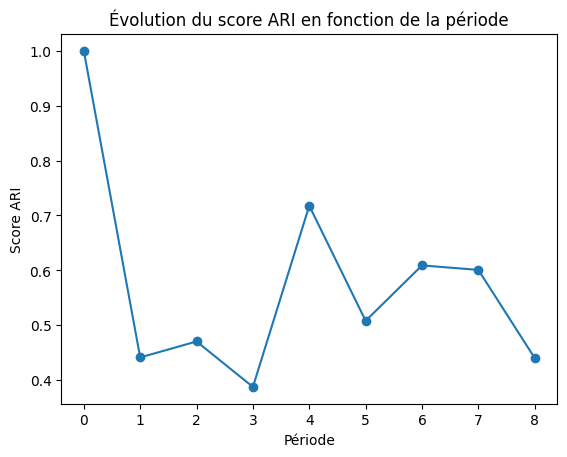

In [120]:
plt.plot(periodes, scores, marker='o')
plt.xlabel('Période')
plt.ylabel('Score ARI')
plt.title('Évolution du score ARI en fonction de la période')
plt.show()